Cell -1 install libraries

In [1]:
pip install pandas numpy matplotlib seaborn yfinance mplfinance scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


CELL 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
import datetime
import os
from sklearn.preprocessing import StandardScaler

CELL 3 — Create Visualization Folder

In [3]:
os.makedirs("visualizations/charts", exist_ok=True)

CELL 4 — Define Market Assets

In [4]:
nifty50 = [
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"SBIN.NS","ITC.NS","LT.NS","HINDUNILVR.NS","KOTAKBANK.NS"
]

us_stocks = [
"AAPL","MSFT","GOOGL","AMZN","NVDA","TSLA","META","AMD","NFLX","INTC"
]

crypto = [
"BTC-USD","ETH-USD","BNB-USD","SOL-USD","XRP-USD",
"ADA-USD","DOGE-USD","TRX-USD","DOT-USD","MATIC-USD"
]

forex = [
"EURUSD=X","GBPUSD=X","USDJPY=X","AUDUSD=X","USDCAD=X","USDINR=X"
]

commodities = [
"GC=F","SI=F","HG=F","CL=F"
]

tickers = nifty50 + us_stocks + crypto + forex + commodities

CELL 5 — Download Real Financial Data

In [5]:
data = yf.download(
    tickers,
    period="2y",
    interval="1d"
)

close_prices = data["Close"]

close_prices.tail()

[*********************100%***********************]  40 of 40 completed


Ticker,AAPL,ADA-USD,AMD,AMZN,AUDUSD=X,BNB-USD,BTC-USD,CL=F,DOGE-USD,DOT-USD,...,SBIN.NS,SI=F,SOL-USD,TCS.NS,TRX-USD,TSLA,USDCAD=X,USDINR=X,USDJPY=X,XRP-USD
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-27,264.179993,0.277620,200.210007,210.000000,0.710180,613.969543,65881.796875,67.019997,0.093370,1.599493,...,1201.699951,92.681999,81.951485,2637.399902,0.282853,402.510010,1.36758,91.007401,155.858994,1.355921
2026-02-28,NaN,0.281615,NaN,NaN,NaN,617.246399,66995.859375,NaN,0.094064,1.670639,...,NaN,NaN,84.366180,NaN,0.281964,NaN,NaN,NaN,NaN,1.377229
2026-03-01,NaN,0.273580,NaN,NaN,NaN,618.107178,65738.101562,NaN,0.091929,1.537121,...,NaN,NaN,83.577660,NaN,0.280707,NaN,NaN,NaN,NaN,1.351729
2026-03-02,264.720001,0.276841,198.619995,208.389999,0.705811,637.239563,68775.851562,71.230003,0.093547,1.509255,...,1189.900024,88.283997,86.634521,2613.500000,0.283338,403.320007,1.36684,91.079597,156.632996,1.390978
2026-03-03,263.750000,0.262839,190.949997,208.729996,0.703433,633.337341,68316.625000,74.800003,0.089956,1.526552,...,NaN,82.300003,85.718750,NaN,0.280711,392.429993,1.36748,92.010002,157.593002,1.362081


CELL 6 — Data Cleaning

In [6]:
close_prices = close_prices.dropna(axis=1, how="all")

returns = close_prices.pct_change().dropna()

print("Assets loaded:", len(close_prices.columns))

Assets loaded: 40


CELL 7 — Price Trend Visualization

<Figure size 1400x700 with 0 Axes>

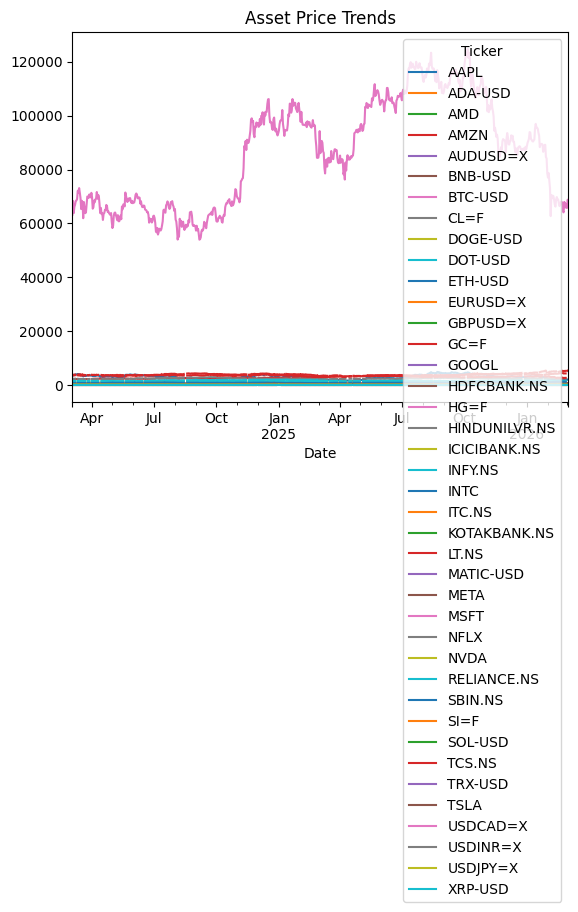

In [7]:
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

plt.figure(figsize=(14,7))
close_prices.plot()

plt.title("Asset Price Trends")

file = f"visualizations/charts/price_trends_{timestamp}.png"

plt.savefig(file)

plt.show()

CELL 8 — Returns Chart

<Figure size 1400x700 with 0 Axes>

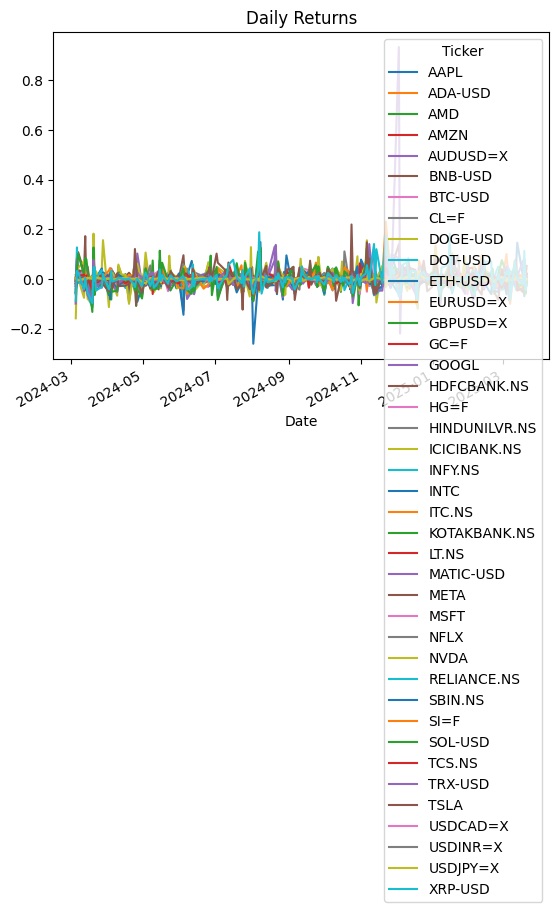

In [8]:
plt.figure(figsize=(14,7))

returns.plot()

plt.title("Daily Returns")

file = f"visualizations/charts/returns_{timestamp}.png"

plt.savefig(file)

plt.show()

CELL 9 — Correlation Heatmap

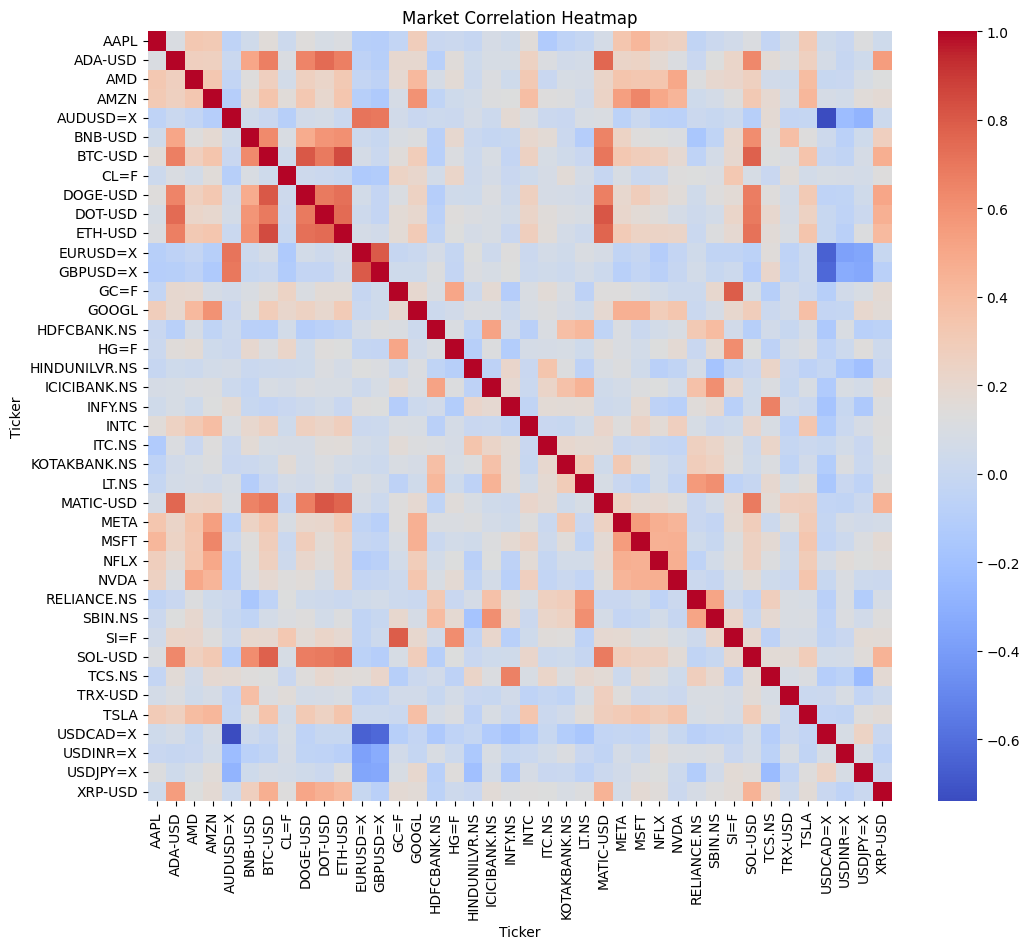

In [9]:
plt.figure(figsize=(12,10))

sns.heatmap(
    returns.corr(),
    cmap="coolwarm"
)

plt.title("Market Correlation Heatmap")

file = f"visualizations/charts/heatmap_{timestamp}.png"

plt.savefig(file)

plt.show()

CELL 10 — Volatility Analysis

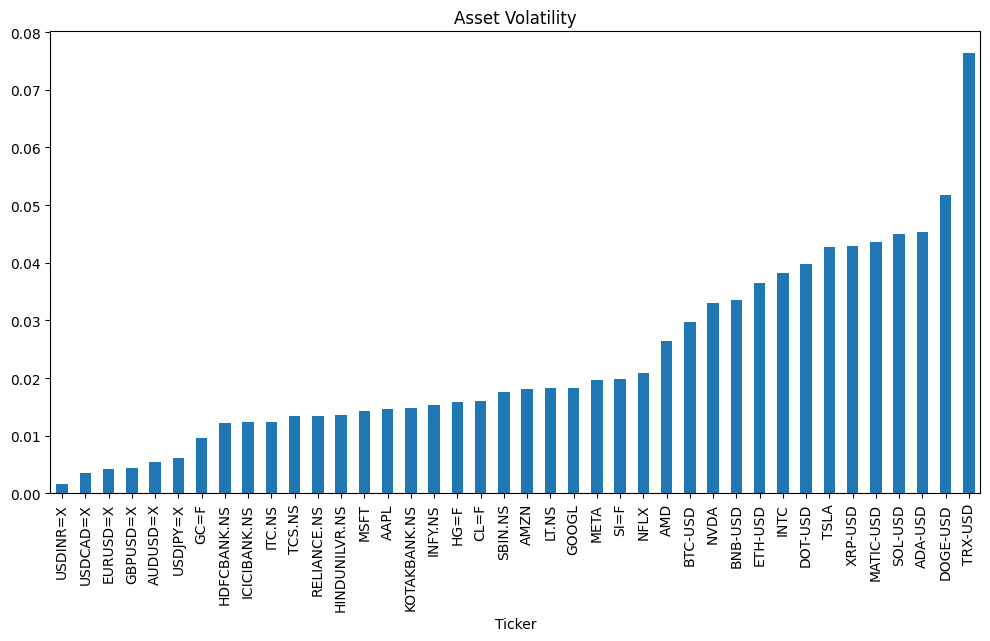

In [10]:
volatility = returns.std()

volatility.sort_values().plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Asset Volatility")

file = f"visualizations/charts/volatility_{timestamp}.png"

plt.savefig(file)

plt.show()

CELL 11 — Sharpe Ratio (Risk-Adjusted Return)

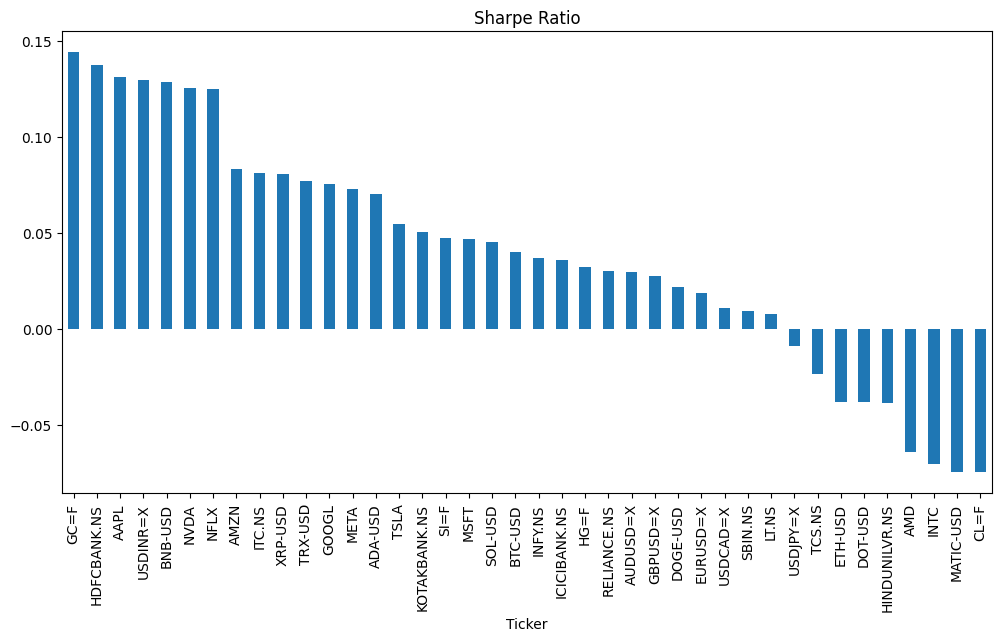

In [11]:
sharpe_ratio = returns.mean() / returns.std()

sharpe_ratio.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Sharpe Ratio")

file = f"visualizations/charts/sharpe_{timestamp}.png"

plt.savefig(file)

plt.show()

CELL 12 — User Selects Asset

In [12]:
print("Select asset for Candlestick Chart:")

assets = {
    "Tesla": "TSLA",
    "Apple": "AAPL",
    "Reliance": "RELIANCE.NS",
    "Bitcoin": "BTC-USD",
    "Ethereum": "ETH-USD",
    "Gold": "GC=F",
    "Silver": "SI=F"
}

for i, name in enumerate(assets.keys()):
    print(f"{i+1}. {name}")

choice = int(input("Enter number: "))

symbol = list(assets.values())[choice-1]

print("Selected:", symbol)

Select asset for Candlestick Chart:
1. Tesla
2. Apple
3. Reliance
4. Bitcoin
5. Ethereum
6. Gold
7. Silver
Selected: AAPL


CELL 13 — Candlestick Chart

In [16]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import datetime

# Timestamp for saving files
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# User-selected symbol
symbol = input("Enter symbol for candlestick chart (e.g., TSLA, BTC-USD): ").upper()

# Download 3 months of data
candle = yf.download(symbol, period="3mo")

# Check if data has multi-level columns
if isinstance(candle.columns, pd.MultiIndex):
    # If multi-index, select first level
    candle.columns = candle.columns.get_level_values(0)

# Keep only necessary columns
candle = candle[['Open','High','Low','Close','Volume']]

# Convert to numeric (coerce invalid values)
for col in ['Open','High','Low','Close','Volume']:
    candle[col] = pd.to_numeric(candle[col], errors='coerce')

# Drop rows with any NaN values
candle = candle.dropna()

# Save chart
file = f"visualizations/charts/candle_{symbol}_{timestamp}.png"

# Plot candlestick
mpf.plot(
    candle,
    type="candle",
    style="yahoo",
    volume=True,
    title=f"{symbol} Candlestick Chart",
    savefig=file
)

print("Candlestick chart saved:", file)

[*********************100%***********************]  1 of 1 completed


Candlestick chart saved: visualizations/charts/candle_TSLA_20260304_035232.png


CELL 14 — Monte Carlo Price Simulation

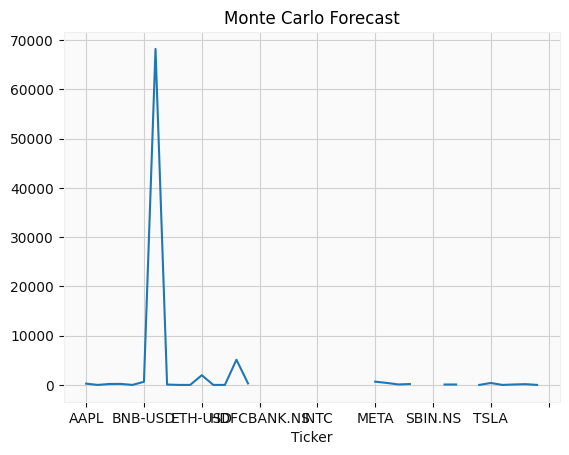

In [17]:
simulations = 100

price = close_prices.iloc[-1]

simulated = []

for i in range(simulations):

    simulated_return = np.random.normal(
        returns.mean(),
        returns.std()
    )

    future_price = price * (1 + simulated_return)

    simulated.append(future_price)

simulated_df = pd.DataFrame(simulated)

simulated_df.mean().plot()

plt.title("Monte Carlo Forecast")

file = f"visualizations/charts/montecarlo_{timestamp}.png"

plt.savefig(file)

plt.show()


CELL 15 — Summary Statistics

In [18]:
summary = pd.DataFrame({
"Mean Return": returns.mean(),
"Volatility": returns.std(),
"Sharpe": sharpe_ratio
})

summary.sort_values("Sharpe", ascending=False).head(10)

,Mean Return,Volatility,Sharpe
Ticker,,,
GC=F,0.001381,0.009586,0.144088
HDFCBANK.NS,0.001671,0.012171,0.137335
AAPL,0.001914,0.014562,0.131430
USDINR=X,0.000206,0.001586,0.129551
BNB-USD,0.004322,0.033560,0.128798
NVDA,0.004144,0.033078,0.125263
NFLX,0.002603,0.020796,0.125155
AMZN,0.001498,0.018015,0.083177
ITC.NS,0.001004,0.012356,0.081237


In [19]:
pip install streamlit yfinance pandas matplotlib seaborn mplfinance

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 9.1/9.1 MB 2.9 MB/s eta 0:00:00
     -------------------------------------- 795.4/795.4 kB 6.3 MB/s eta 0:00:00
     -------------------------------------- 108.3/108.3 kB 6.1 MB/s eta 0:00:00
     -------------------------------------- 208.6/208.6 kB 6.4 MB/s eta 0:00:00
     ---------------------------------------- 11.3/11.3 MB 6.4 MB/s eta 0:00:00
     ---------------------------------------- 6.9/6.9 MB 6.5 MB/s eta 0:00:00
     -------------------------------------- 437.1/437.1 kB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 27.5/27.5 MB 6.3 MB/s eta 0:00:00
     ---------------------------------------- 79.1/79.1 kB ? eta 0:00:00
     -------------------------------------- 134.9/134.9 kB 8.3 MB/s eta 0:00:00
     ---------------------------------------- 90.6/90.6 kB 2.5 MB/s eta 0:00:00
     ---------------------------------------- 62.8/62

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\SRI HARSHA\\AppData\\Roaming\\Python\\Python311\\site-packages\\google\\~upb\\_message.pyd'
Check the permissions.


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
import plotly.express as px
import plotly.graph_objects as go
import datetime
import os

# Create folders
os.makedirs("visualizations/charts", exist_ok=True)

# ===============================
# USER INPUT
# ===============================
symbols = input("Enter symbols (comma separated, e.g., TSLA,AAPL,BTC-USD): ").upper().split(",")
period = input("Enter period (1mo,3mo,6mo,1y,5y): ")
interval = "1d"

# ===============================
# DOWNLOAD DATA
# ===============================
data = yf.download(symbols, period=period, interval=interval)
close = data["Close"]

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

print("\nDownloaded Data:")
display(close.tail())

# ===============================
# RETURNS CALCULATION
# ===============================
returns = close.pct_change().dropna()

# ===============================
# RETURNS CHART (Plotly)
# ===============================
fig_returns = px.line(returns, title="Returns Chart")
returns_file = f"visualizations/charts/returns_{timestamp}.html"
fig_returns.write_html(returns_file)
fig_returns.show()
print("Interactive Returns chart saved:", returns_file)

# ===============================
# CORRELATION HEATMAP (Plotly)
# ===============================
corr = returns.corr()
fig_heatmap = px.imshow(corr, text_auto=True, color_continuous_scale="RdBu_r", title="Correlation Heatmap")
heatmap_file = f"visualizations/charts/heatmap_{timestamp}.html"
fig_heatmap.write_html(heatmap_file)
fig_heatmap.show()
print("Interactive Heatmap saved:", heatmap_file)

# ===============================
# CANDLESTICK CHARTS
# ===============================
for symbol in symbols:
    df = yf.download(symbol, period="3mo", interval="1d")
    df = df[['Open','High','Low','Close','Volume']]
    for col in ['Open','High','Low','Close','Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()
    
    candle_file = f"visualizations/charts/candlestick_{symbol}_{timestamp}.png"
    mpf.plot(df, type="candle", style="yahoo", volume=True, title=f"{symbol} Candlestick", savefig=candle_file)
    print(f"Candlestick saved: {candle_file}")

# ===============================
# PORTFOLIO RISK & PnL CALCULATOR
# ===============================
# User inputs weights and buy prices
weights = []
buy_prices = []
for s in symbols:
    w = float(input(f"Enter weight of {s} in portfolio (0-1): "))
    weights.append(w)
    p = float(input(f"Enter your buy price for {s}: "))
    buy_prices.append(p)

weights = np.array(weights)
buy_prices = np.array(buy_prices)

# Portfolio return and variance
mean_returns = returns.mean()
cov_matrix = returns.cov()

portfolio_return = np.dot(weights, mean_returns) * 252  # annualized
portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix*252, weights)))  # annualized
sharpe_ratio = portfolio_return / portfolio_volatility

# Current PnL
latest_prices = close.iloc[-1].values
pnl = (latest_prices - buy_prices) * weights.sum()  # simplified for demonstration

print("\nPortfolio Analysis:")
print(f"Annualized Return: {portfolio_return:.2%}")
print(f"Annualized Volatility: {portfolio_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"PnL based on current prices: {pnl}")

[*********************100%***********************]  1 of 1 completed


Downloaded Data:


Ticker,ETH-USD
Date,
2026-02-27,1930.761841
2026-02-28,1965.050537
2026-03-01,1939.066650
2026-03-02,2027.268921
2026-03-03,1980.913696


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed